# USPTO Patent Activity — U.S. State Choropleth Map
### Hetvi Chavda · Data Visualization · Northeastern University

**Project Overview**

This notebook analyses utility patent grant activity across all 50 U.S. states using data from the United States Patent and Trademark Office (USPTO). It builds two views of the same data — a raw count choropleth and a per-capita choropleth — to surface the key insight that California's raw dominance looks very different once you adjust for population.

**Stack:** Python · GeoPandas · Matplotlib · Plotly · Pandas

**Data Sources:**
- USPTO Utility Patent Grants by CBSA Metropolitan Area — 2015
- Census TIGER/Line State Boundary Shapefile (tl_2020_us_state)
- U.S. Census Bureau 2015 Population Estimates

**Files Required (all in the same folder as this notebook):**
```
Patents.csv
tl_2020_us_state/
    tl_2020_us_state.shp
    tl_2020_us_state.dbf
    tl_2020_us_state.shx
    tl_2020_us_state.prj
    tl_2020_us_state.cpg
```

In [1]:
!pip install geopandas pandas plotly matplotlib openpyxl -q

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

BASE = "/Users/hetvichavda/Downloads"
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Step 1 — Load State Boundary Shapefile with GeoPandas

The Census TIGER/Line shapefile contains polygon boundaries for every U.S. state and territory. GeoPandas reads all component files (`.shp`, `.dbf`, `.shx`, `.prj`) together and returns a GeoDataFrame.

We reproject to **WGS84 (EPSG:4326)** — the standard lat/lon coordinate system — so the data is compatible with Plotly's mapping engine.

In [14]:
states_gdf = gpd.read_file(f"{BASE}/tl_2020_us_state/tl_2020_us_state.shp")

# Reproject to WGS84 for Plotly compatibility
states_gdf = states_gdf.to_crs(epsg=4326)

# Keep 50 states + DC, exclude territories
# STUSPS is the state abbreviation column — confirmed from DBF header
states_gdf = states_gdf[
    ~states_gdf["STUSPS"].isin(["PR", "VI", "GU", "MP", "AS"])
].copy()

print(f"Loaded: {len(states_gdf)} state polygons")
print(f"CRS:    {states_gdf.crs}")
states_gdf[["NAME", "STUSPS", "ALAND"]].head()

Loaded: 51 state polygons
CRS:    EPSG:4326


,NAME,STUSPS,ALAND
0,West Virginia,WV,62266296765
1,Florida,FL,138958484319
2,Illinois,IL,143778461053
3,Minnesota,MN,206232157570
4,Maryland,MD,25151895765


---
## Step 2 — Load and Process USPTO Patent Data

The USPTO data contains patent grant counts by metropolitan area (CBSA). Since patents are attributed to metro areas rather than states directly, we extract the primary state from each metro name and aggregate to state level.

For example: `"Boston-Cambridge-Quincy, MA-NH"` → primary state `"MA"`

In [15]:
df_raw = pd.read_csv(f"{BASE}/Patents.csv", encoding="latin1")
df_raw = df_raw.dropna(subset=["Patents_2015"])

print(f"Loaded {len(df_raw):,} metro area records")
df_raw.head()

Loaded 1,023 metro area records


,CBSA_Code1,CBSA_Code,MSA_Name,Patents_2015
0,41940,141940,"San Jose-Sunnyvale-Santa Clara, CA",14618.0
1,35620,135620,"New York-Northern New Jersey-Long Island, NY-N...",7754.0
2,41860,141860,"San Francisco-Oakland-Fremont, CA",9732.0
3,31100,131100,"Los Angeles-Long Beach-Santa Ana, CA",6476.0
4,14460,114460,"Boston-Cambridge-Quincy, MA-NH",5949.0


In [16]:
def extract_primary_state(msa_name):
    """
    Extract the primary state abbreviation from a metro area name.

    MSA names follow the pattern: "City Name, ST" or
    "City Name, ST1-ST2-ST3" for multi-state metros.
    We take the first (primary) state code after the final comma.

    Examples:
        "San Jose-Sunnyvale-Santa Clara, CA"      ->  "CA"
        "New York-Northern New Jersey, NY-NJ-PA"  ->  "NY"
        "Boston-Cambridge-Quincy, MA-NH"          ->  "MA"
    """
    parts = str(msa_name).split(",")
    if len(parts) > 1:
        state_part = parts[-1].strip()
        primary = state_part.split("-")[0].strip()
        if len(primary) == 2 and primary.isalpha():
            return primary.upper()
    return None


df_raw["State"] = df_raw["MSA_Name"].apply(extract_primary_state)
df_clean = df_raw[df_raw["State"].notna()].copy()

state_patents = (
    df_clean
    .groupby("State")["Patents_2015"]
    .sum()
    .reset_index()
    .rename(columns={"Patents_2015": "Patents"})
)
state_patents["Patents"] = state_patents["Patents"].astype(int)

print(f"Valid state-attributed records: {len(df_clean):,}")
print(f"Aggregated to {len(state_patents)} states")
state_patents.nlargest(10, "Patents")

Valid state-attributed records: 1,018
Aggregated to 56 states


,State,Patents
4,CA,40134
36,NY,12244
46,TX,9938
20,MA,6846
52,WA,6138
23,MI,5550
15,IL,4992
24,MN,4440
40,PA,4439
9,FL,4057


---
## Step 3 — Add Population and Compute Per-Capita Rates

Raw counts favour large states simply because they have more people. Normalising by population (patents per 100,000 residents) reveals which states are proportionally more innovative — often a very different picture.

In [17]:
# 2015 U.S. Census Bureau population estimates
population_2015 = {
    "AK": 738432,   "AL": 4858979,  "AR": 2978204,  "AZ": 6828065,
    "CA": 39144818, "CO": 5456574,  "CT": 3590886,  "DC": 672228,
    "DE": 945934,   "FL": 20271272, "GA": 10214860, "HI": 1431603,
    "IA": 3123899,  "ID": 1654930,  "IL": 12859995, "IN": 6619680,
    "KS": 2911641,  "KY": 4425092,  "LA": 4670724,  "MA": 6794422,
    "MD": 6006401,  "ME": 1329328,  "MI": 9922576,  "MN": 5489594,
    "MO": 6083672,  "MS": 2992333,  "MT": 1032949,  "NC": 10042802,
    "ND": 756927,   "NE": 1896190,  "NH": 1330608,  "NJ": 8958013,
    "NM": 2085109,  "NV": 2890845,  "NY": 19795791, "OH": 11613423,
    "OK": 3911338,  "OR": 4028977,  "PA": 12802503, "RI": 1056298,
    "SC": 4896146,  "SD": 858469,   "TN": 6600299,  "TX": 27469114,
    "UT": 2995919,  "VA": 8382993,  "VT": 626042,   "WA": 7170351,
    "WI": 5771337,  "WV": 1844128,  "WY": 586107,
}

state_patents["Population"] = state_patents["State"].map(population_2015)
state_patents = state_patents.dropna(subset=["Population"])
state_patents["Population"] = state_patents["Population"].astype(int)

# Patents per 100,000 people
state_patents["PerCapita"] = (
    (state_patents["Patents"] / state_patents["Population"]) * 100_000
).round(1)

print("Top 5 by raw count:")
for _, r in state_patents.nlargest(5, "Patents").iterrows():
    print(f"  {r['State']}: {r['Patents']:,}")

print("\nTop 5 by per capita (per 100K):")
for _, r in state_patents.nlargest(5, "PerCapita").iterrows():
    print(f"  {r['State']}: {r['PerCapita']}")

Top 5 by raw count:
  CA: 40,134
  NY: 12,244
  TX: 9,938
  MA: 6,846
  WA: 6,138

Top 5 by per capita (per 100K):
  DC: 343.6
  CA: 102.5
  MA: 100.8
  WA: 85.6
  MN: 80.9


---
## Step 4 — Spatial Merge: Attach Patent Data to State Polygons

This is the core GeoPandas operation. We merge the patent DataFrame onto the GeoDataFrame using the state abbreviation (`STUSPS`) as the join key. After the merge, each polygon carries its patent count and per-capita rate as attributes — ready to colour as a choropleth.

In [18]:
merged_gdf = states_gdf.merge(
    state_patents,
    left_on="STUSPS",
    right_on="State",
    how="left"
)

merged_gdf["Patents"]    = merged_gdf["Patents"].fillna(0).astype(int)
merged_gdf["PerCapita"]  = merged_gdf["PerCapita"].fillna(0.0)
merged_gdf["Population"] = merged_gdf["Population"].fillna(0).astype(int)

print(f"Merged: {len(merged_gdf)} state polygons")
print(f"States with data: {merged_gdf['Patents'].gt(0).sum()}")
merged_gdf[["NAME", "STUSPS", "Patents", "PerCapita", "Population"]].sort_values("Patents", ascending=False).head(10)

Merged: 51 state polygons
States with data: 51


,NAME,STUSPS,Patents,PerCapita,Population
13,California,CA,40134,102.5,39144818
35,New York,NY,12244,61.9,19795791
25,Texas,TX,9938,36.2,27469114
46,Massachusetts,MA,6846,100.8,6794422
19,Washington,WA,6138,85.6,7170351
38,Michigan,MI,5550,55.9,9922576
2,Illinois,IL,4992,38.8,12859995
3,Minnesota,MN,4440,80.9,5489594
18,Pennsylvania,PA,4439,34.7,12802503
1,Florida,FL,4057,20.0,20271272


---
## Step 5 — Matplotlib Static Choropleth (Side-by-Side)

We use **Albers Equal Area USA (EPSG:5070)** — the standard cartographic projection for U.S. thematic maps — which correctly preserves area relationships. The two panels show raw count (left) and per-capita rate (right), saved as a high-resolution PNG.

Saved: uspto_choropleth_matplotlib.png


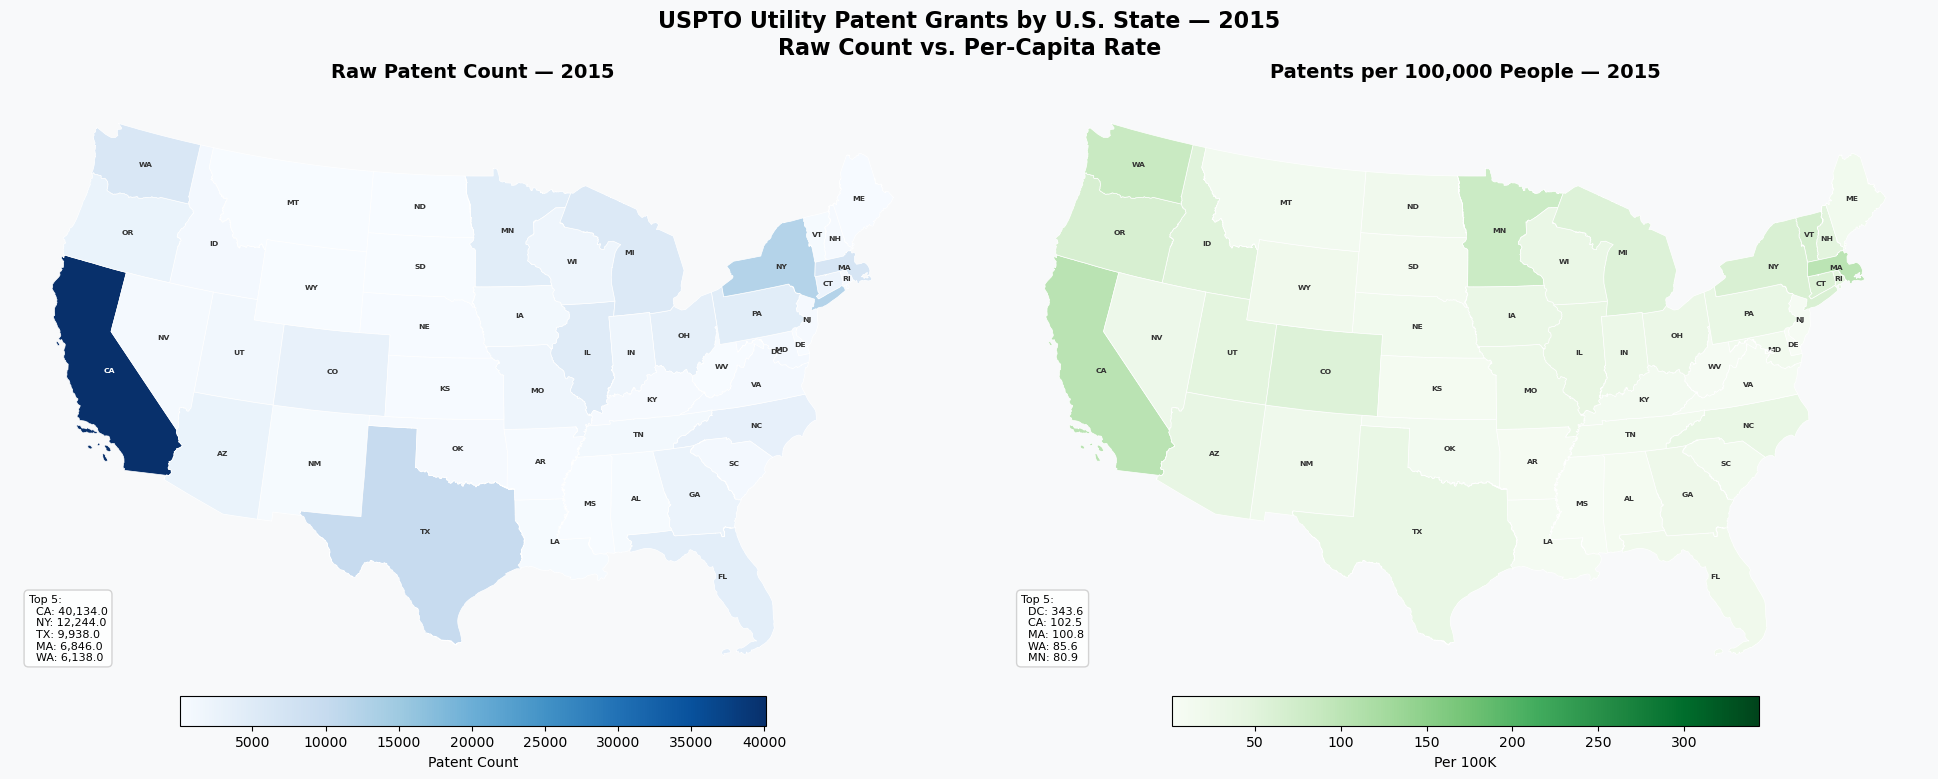

In [19]:
# EPSG:5070 = Albers Equal Area Conic USA — standard for US thematic maps
merged_proj = merged_gdf.to_crs("EPSG:5070")
continental = merged_proj[~merged_proj["STUSPS"].isin(["AK", "HI"])]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor("#F8F9FA")

for idx, (col, title, cmap_name, bar_label) in enumerate([
    ("Patents",   "Raw Patent Count — 2015",          "Blues",  "Patent Count"),
    ("PerCapita", "Patents per 100,000 People — 2015", "Greens", "Per 100K"),
]):
    ax = axes[idx]
    ax.set_facecolor("#E8F4F8")

    continental.plot(
        column=col, ax=ax, cmap=cmap_name,
        linewidth=0.5, edgecolor="white",
        legend=True,
        legend_kwds={
            "label": bar_label,
            "orientation": "horizontal",
            "shrink": 0.6,
            "pad": 0.02
        }
    )

    norm = mcolors.Normalize(
        vmin=continental[col].min(),
        vmax=continental[col].max()
    )

    for _, row in continental.iterrows():
        if row["geometry"] is not None and row["STUSPS"]:
            centroid = row["geometry"].centroid
            ax.annotate(
                row["STUSPS"],
                xy=(centroid.x, centroid.y),
                ha="center", va="center",
                fontsize=5.5, fontweight="bold",
                color="white" if norm(row[col]) > 0.55 else "#333"
            )

    top5 = continental.nlargest(5, col)[["STUSPS", col]]
    note = "Top 5:\n" + "\n".join(
        f"  {r['STUSPS']}: {r[col]:,.1f}" for _, r in top5.iterrows()
    )
    ax.text(
        0.02, 0.15, note, transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="#CCC")
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=14)
    ax.axis("off")

plt.suptitle(
    "USPTO Utility Patent Grants by U.S. State — 2015\nRaw Count vs. Per-Capita Rate",
    fontsize=16, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{BASE}/uspto_choropleth_matplotlib.png", dpi=150, bbox_inches="tight")
print("Saved: uspto_choropleth_matplotlib.png")
plt.show()

---
## Step 6 — Interactive Plotly Choropleth Maps

Plotly matches state abbreviations to its built-in US GeoJSON using `locationmode='USA-states'`. The colour values come from our spatially merged GeoDataFrame — ensuring correct attribution. Hover over any state for full details.

In [20]:
def build_plotly_map(mode="raw"):
    """
    Build an interactive Plotly choropleth map.

    Args:
        mode: "raw" for total patent count, "percapita" for per 100K
    """
    is_pc  = (mode == "percapita")
    z_col  = "PerCapita" if is_pc else "Patents"
    title  = (
        "USPTO Patent Grants per 100,000 People by State — 2015"
        if is_pc else
        "USPTO Utility Patent Grants by State — 2015 (Raw Count)"
    )
    colorscale = (
        [[0, "#F0FFF4"], [0.2, "#A9DFBF"], [0.4, "#27AE60"],
         [0.7, "#196F3D"], [1.0, "#0B3B1F"]]
        if is_pc else
        [[0, "#EBF5FB"], [0.2, "#AED6F1"], [0.4, "#2980B9"],
         [0.7, "#1A5276"], [1.0, "#0B2545"]]
    )

    def hover_label(r):
        if r["Patents"] > 0:
            return (
                f"<b>{r['NAME']} ({r['STUSPS']})</b><br>"
                f"Patents: {r['Patents']:,}<br>"
                f"Per 100K: {r['PerCapita']}<br>"
                f"Population: {r['Population']:,}"
            )
        return f"<b>{r['NAME']}</b><br>No CBSA data"

    hover_text = merged_gdf.apply(hover_label, axis=1)

    fig = go.Figure(go.Choropleth(
        locationmode="USA-states",
        locations=merged_gdf["STUSPS"],
        z=merged_gdf[z_col],
        text=hover_text,
        hoverinfo="text",
        colorscale=colorscale,
        colorbar=dict(
            title=dict(text="Per 100K" if is_pc else "Patents", font=dict(size=13)),
            tickfont=dict(size=11)
        ),
        marker=dict(line=dict(color="white", width=1))
    ))

    fig.update_layout(
        title=dict(text=title, font=dict(size=16), x=0.5),
        geo=dict(
            scope="usa",
            showland=True, landcolor="#F0F0F0",
            showcoastlines=True, coastlinecolor="#AAAAAA",
            showframe=False
        ),
        height=520,
        margin=dict(l=0, r=0, t=60, b=0),
        paper_bgcolor="white"
    )
    return fig

fig_raw = build_plotly_map("raw")
fig_raw.write_html(f"{BASE}/uspto_plotly_raw.html")
print("Saved: uspto_plotly_raw.html")
fig_raw.show()

Saved: uspto_plotly_raw.html


In [21]:
fig_pc = build_plotly_map("percapita")
fig_pc.write_html(f"{BASE}/uspto_plotly_percapita.html")
print("Saved: uspto_plotly_percapita.html")
fig_pc.show()

Saved: uspto_plotly_percapita.html


---
## Step 7 — Side-by-Side Ranking Comparison

The key analytical insight: California leads in raw counts by a wide margin, but on a per-capita basis DC, Massachusetts, and Washington rank far higher. The two rankings tell completely different stories about where innovation is concentrated.

In [22]:
top_raw = state_patents.nlargest(15, "Patents").sort_values("Patents", ascending=True)
top_pc  = state_patents.nlargest(15, "PerCapita").sort_values("PerCapita", ascending=True)

fig_comp = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Top 15 — Raw Patent Count", "Top 15 — Per 100,000 People"),
    horizontal_spacing=0.12
)

fig_comp.add_trace(go.Bar(
    x=top_raw["Patents"], y=top_raw["State"],
    orientation="h",
    marker=dict(color="#2980B9", line=dict(width=0)),
    text=top_raw["Patents"].apply(lambda x: f"{x:,}"),
    textposition="outside",
    showlegend=False,
    hovertemplate="<b>%{y}</b><br>Patents: %{x:,}<extra></extra>"
), row=1, col=1)

fig_comp.add_trace(go.Bar(
    x=top_pc["PerCapita"], y=top_pc["State"],
    orientation="h",
    marker=dict(color="#27AE60", line=dict(width=0)),
    text=top_pc["PerCapita"].apply(lambda x: f"{x:.1f}"),
    textposition="outside",
    showlegend=False,
    hovertemplate="<b>%{y}</b><br>Per 100K: %{x:.1f}<extra></extra>"
), row=1, col=2)

fig_comp.update_layout(
    title="Raw Count vs. Per-Capita: Two Very Different Stories of Innovation",
    height=520,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(size=12)
)
fig_comp.update_xaxes(showgrid=True, gridcolor="#EEE")
fig_comp.update_yaxes(showgrid=False)
fig_comp.write_html(f"{BASE}/uspto_comparison.html")
print("Saved: uspto_comparison.html")
fig_comp.show()

Saved: uspto_comparison.html


---
## Step 8 — Top Metro Areas

Metro-level breakdown of the top 15 patent-producing areas. Silicon Valley's San Jose metro leads by a large margin — nearly double the second-ranked metro.

Saved: uspto_metro_areas.html


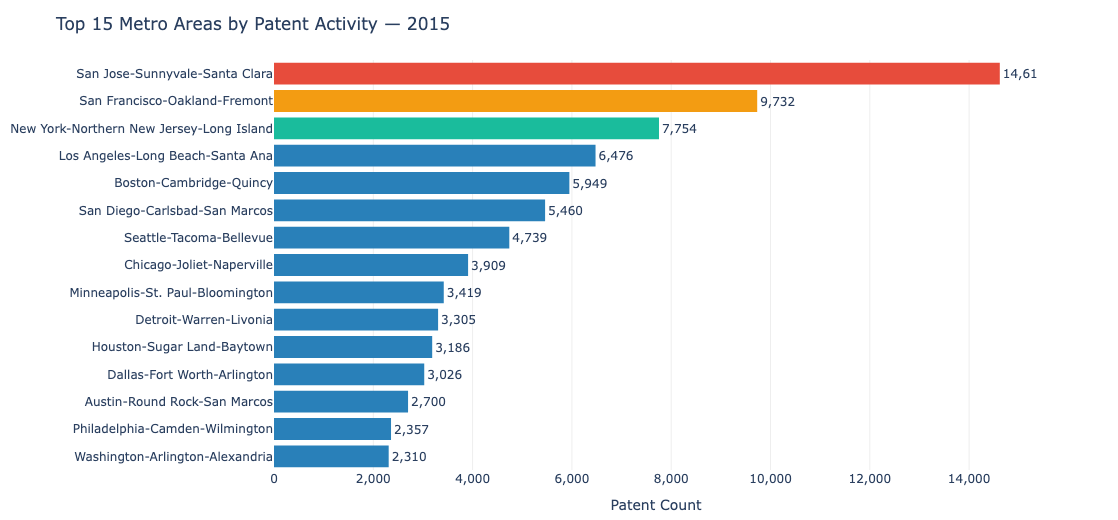

In [23]:
top_metros = (
    df_clean[~df_clean["MSA_Name"].str.startswith("--")]
    .nlargest(15, "Patents_2015")[["MSA_Name", "Patents_2015"]]
    .sort_values("Patents_2015", ascending=True)
)
top_metros["Short"] = top_metros["MSA_Name"].apply(
    lambda x: x.split(",")[0] if "," in x else x[:45]
)

# Colour top 3 distinctively
bar_colors = ["#2980B9"] * 12 + ["#1ABC9C", "#F39C12", "#E74C3C"]

fig_metro = go.Figure(go.Bar(
    x=top_metros["Patents_2015"],
    y=top_metros["Short"],
    orientation="h",
    marker=dict(color=bar_colors, line=dict(width=0)),
    text=top_metros["Patents_2015"].apply(lambda x: f"{int(x):,}"),
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>Patents: %{x:,}<extra></extra>"
))

fig_metro.update_layout(
    title="Top 15 Metro Areas by Patent Activity — 2015",
    xaxis=dict(title="Patent Count", showgrid=True, gridcolor="#EEE", tickformat=","),
    yaxis=dict(showgrid=False),
    margin=dict(l=10, r=80, t=60, b=50),
    paper_bgcolor="white",
    plot_bgcolor="white",
    height=520,
    font=dict(size=12)
)
fig_metro.write_html(f"{BASE}/uspto_metro_areas.html")
print("Saved: uspto_metro_areas.html")
fig_metro.show()

---
## Summary

| Output File | Description |
|---|---|
| `uspto_choropleth_matplotlib.png` | Static side-by-side choropleth (Matplotlib + GeoPandas) |
| `uspto_plotly_raw.html` | Interactive raw count choropleth (Plotly) |
| `uspto_plotly_percapita.html` | Interactive per-capita choropleth (Plotly) |
| `uspto_comparison.html` | Side-by-side state rankings — raw vs per capita |
| `uspto_metro_areas.html` | Top 15 metro areas bar chart |

**Key Finding:** California leads in raw patent volume (40,134 patents) but when adjusted for population, DC leads at 343.6 per 100K, followed by Massachusetts (100.8) and California (102.5). The per-capita view reveals innovation-dense smaller geographies that raw counts obscure.